<a href="https://colab.research.google.com/github/Arpit11-svg/DL/blob/main/Attention_heatMapIn_Seq2Seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch matplotlib seaborn

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
pairs = [
    ["hello", "bonjour"],
    ["good night", "bonne nuit"],
    ["thank you", "merci"]
]

In [5]:
word2index = {"PAD":0}

def add_sentence(sentence):
    for word in sentence.split():
        if word not in word2index:
            word2index[word] = len(word2index)

for p in pairs:
    add_sentence(p[0])
    add_sentence(p[1])

vocab_size = len(word2index)

In [6]:
def tensor(sentence):
    return torch.tensor(
        [word2index[w] for w in sentence.split()],
        dtype=torch.long
    ).view(-1,1)

In [7]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, 8)
        self.gru = nn.GRU(8, 8)

    def forward(self, x, hidden):

        x = self.embed(x).view(1,1,-1)

        output, hidden = self.gru(x, hidden)

        return output, hidden

    def initHidden(self):
        return torch.zeros(1,1,8)

In [8]:
class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, 8)

        self.attn = nn.Linear(16, 5)

        self.combine = nn.Linear(16, 8)

        self.gru = nn.GRU(8,8)

        self.out = nn.Linear(8, vocab_size)

    def forward(self, x, hidden, encoder_outputs):

        x = self.embed(x).view(1,1,-1)

        attn_weights = torch.softmax(
            self.attn(torch.cat((x[0], hidden[0]),1)),
            dim=1
        )

        attn_applied = torch.bmm(
            attn_weights.unsqueeze(0),
            encoder_outputs.unsqueeze(0)
        )

        output = torch.cat((x[0], attn_applied[0]),1)

        output = self.combine(output).unsqueeze(0)

        output = torch.relu(output)

        output, hidden = self.gru(output, hidden)

        output = self.out(output[0])

        return output, hidden, attn_weights

In [9]:
encoder = Encoder()

decoder = Decoder()

loss_fn = nn.CrossEntropyLoss()

enc_opt = optim.Adam(encoder.parameters(), lr=0.01)

dec_opt = optim.Adam(decoder.parameters(), lr=0.01)

In [10]:
for epoch in range(200):

    total_loss = 0

    for pair in pairs:

        inp = tensor(pair[0])

        target = tensor(pair[1])

        hidden = encoder.initHidden()

        enc_opt.zero_grad()

        dec_opt.zero_grad()

        encoder_outputs = torch.zeros(5,8)

        # Encoder
        for i in range(inp.size(0)):

            out, hidden = encoder(inp[i], hidden)

            encoder_outputs[i] = out[0,0]

        decoder_input = torch.tensor([[0]])

        decoder_hidden = hidden

        loss = 0

        # Decoder
        for i in range(target.size(0)):

            output, decoder_hidden, attn = decoder(
                decoder_input,
                decoder_hidden,
                encoder_outputs
            )

            loss += loss_fn(output, target[i])

            decoder_input = target[i]

        loss.backward()

        enc_opt.step()

        dec_opt.step()

        total_loss += loss.item()

    if epoch % 50 == 0:
        print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 8.645830631256104
Epoch: 50 Loss: 0.16550810635089874
Epoch: 100 Loss: 0.06160924397408962
Epoch: 150 Loss: 0.03388428408652544


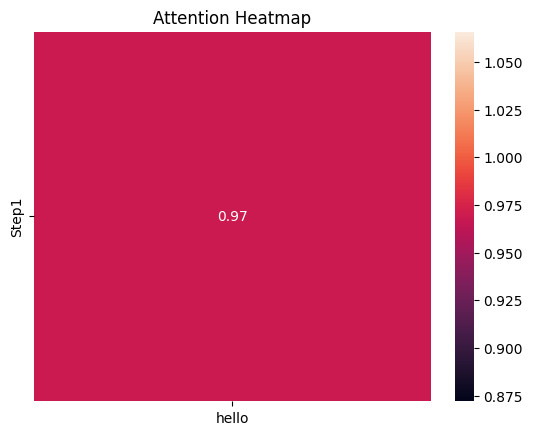

In [11]:
sentence = "hello"

inp = tensor(sentence)

hidden = encoder.initHidden()

encoder_outputs = torch.zeros(5,8)

for i in range(inp.size(0)):

    out, hidden = encoder(inp[i], hidden)

    encoder_outputs[i] = out[0,0]

decoder_input = torch.tensor([[0]])

attention_list = []

for i in range(inp.size(0)):

    output, hidden, attn = decoder(
        decoder_input,
        hidden,
        encoder_outputs
    )

    attention_list.append(
        attn.detach().numpy()[0][:inp.size(0)]
    )

    decoder_input = torch.argmax(output).view(1,1)

attention = np.array(attention_list)

sns.heatmap(
    attention,
    annot=True,
    xticklabels=sentence.split(),
    yticklabels=["Step1"]
)

plt.title("Attention Heatmap")

plt.show()